# 06 — From forecasts to staffing decisions

Forecast accuracy is only an intermediate metric; the deliverable is a roster.
This notebook converts demand forecasts into recommended staffing levels per
clinic and day, compares them against each clinic's baseline staffing, and
examines the cost consequences of forecast uncertainty.

The decision rules are intentionally simple and fully transparent — every
number can be traced to an assumption in `configs/staffing.yaml`. In a real
deployment these assumptions are negotiated with operations leaders, not
chosen by data scientists.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.figsize"] = (11, 4)

In [2]:
from clinic_forecast.data import generate_network_data
from clinic_forecast.models.baseline import seasonal_naive_forecast
from clinic_forecast.staffing import StaffingRules, recommend_staffing, staffing_gap

processed = PROJECT_ROOT / "data" / "processed"
data_path = processed / "clinic_daily_usage.csv"
metadata_path = processed / "clinic_metadata.csv"

if data_path.exists() and metadata_path.exists():
    usage = pd.read_csv(data_path, parse_dates=["date"])
    metadata = pd.read_csv(metadata_path)
else:
    network = generate_network_data()
    usage, metadata = network.usage, network.metadata
    usage["date"] = pd.to_datetime(usage["date"])

cutoff = usage["date"].max() - pd.Timedelta(days=28)
train = usage[usage["date"] <= cutoff]
future = usage[usage["date"] > cutoff]
forecast = seasonal_naive_forecast(train=train, future=future)
print(f"Planning window: {future['date'].min():%Y-%m-%d} to {future['date'].max():%Y-%m-%d}")

Planning window: 2025-12-04 to 2025-12-31


For this demonstration the input is the seasonal-naive forecast over the final
28 days. The decision layer is forecast-agnostic by design — swapping in the
global ML forecast from notebook 04 (or, later, its upper interval bound)
changes one line. Using the weakest forecast here is also informative: it
shows how forecast error propagates into staffing error.

## Staffing rules

Productivity and minimum-coverage assumptions, mirroring
`configs/staffing.yaml`:

- A clinician handles ~18 visits/day, a nurse ~24, front-desk ~35.
- Every open clinic needs at least one of each role regardless of demand.
- A 12% demand buffer covers within-day arrival peaks: daily totals hide
  intra-day spikes, so staffing exactly to the mean guarantees queueing.

In [3]:
rules = StaffingRules(
    visits_per_clinician_day=18,
    visits_per_nurse_day=24,
    visits_per_frontdesk_day=35,
    minimum_clinicians=1,
    minimum_nurses=1,
    minimum_frontdesk=1,
    buffer_ratio=0.12,
)
staffed = recommend_staffing(forecast, rules=rules)
staffed.head(10)

,clinic_id,date,forecast,model,recommended_clinicians,recommended_nurses,recommended_frontdesk
0,CLINIC_001,2025-12-04,106.0,seasonal_naive,7,5,4
1,CLINIC_001,2025-12-05,41.0,seasonal_naive,3,2,2
2,CLINIC_001,2025-12-06,40.0,seasonal_naive,3,2,2
3,CLINIC_001,2025-12-07,0.0,seasonal_naive,1,1,1
4,CLINIC_001,2025-12-08,98.0,seasonal_naive,7,5,4
5,CLINIC_001,2025-12-09,87.0,seasonal_naive,6,5,3
6,CLINIC_001,2025-12-10,131.0,seasonal_naive,9,7,5
7,CLINIC_001,2025-12-11,106.0,seasonal_naive,7,5,4
8,CLINIC_001,2025-12-12,41.0,seasonal_naive,3,2,2
9,CLINIC_001,2025-12-13,40.0,seasonal_naive,3,2,2


## Recommended vs baseline staffing

Each clinic has a static baseline roster (metadata). The gap between
recommendation and baseline is the actionable output: positive gaps are
days where the baseline roster is predicted to be short (service risk),
negative gaps are days of predicted idle capacity (cost).

In [4]:
gaps = staffing_gap(staffed, metadata)
gap_summary = gaps.groupby("clinic_id").agg(
    mean_clinician_gap=("clinician_gap", "mean"),
    days_short=("clinician_gap", lambda s: int((s > 0).sum())),
    days_over=("clinician_gap", lambda s: int((s < 0).sum())),
    max_shortfall=("clinician_gap", "max"),
).round(2)
gap_summary.sort_values("mean_clinician_gap", ascending=False)

,mean_clinician_gap,days_short,days_over,max_shortfall
clinic_id,,,,
CLINIC_009,-0.86,16,12,2
CLINIC_007,-1.29,4,20,2
CLINIC_002,-1.57,8,20,3
CLINIC_001,-1.86,4,16,2
CLINIC_011,-1.86,4,16,2
CLINIC_003,-2.29,0,28,-1
CLINIC_006,-2.29,8,20,1
CLINIC_012,-2.29,8,20,3
CLINIC_005,-2.43,0,28,-2


In [5]:
total_short_days = int((gaps["clinician_gap"] > 0).sum())
total_over_days = int((gaps["clinician_gap"] < 0).sum())
print(f"Clinic-days with predicted clinician shortfall: {total_short_days}")
print(f"Clinic-days with predicted idle clinician capacity: {total_over_days}")

Clinic-days with predicted clinician shortfall: 52
Clinic-days with predicted idle clinician capacity: 260


The pattern is typical of static rosters against cyclical demand: the same
clinic can be short on Mondays and over-staffed on Saturdays within one week.
A static baseline cannot be right on both; demand-driven rostering converts
this weekly mismatch directly into either recovered cost or recovered service
level.

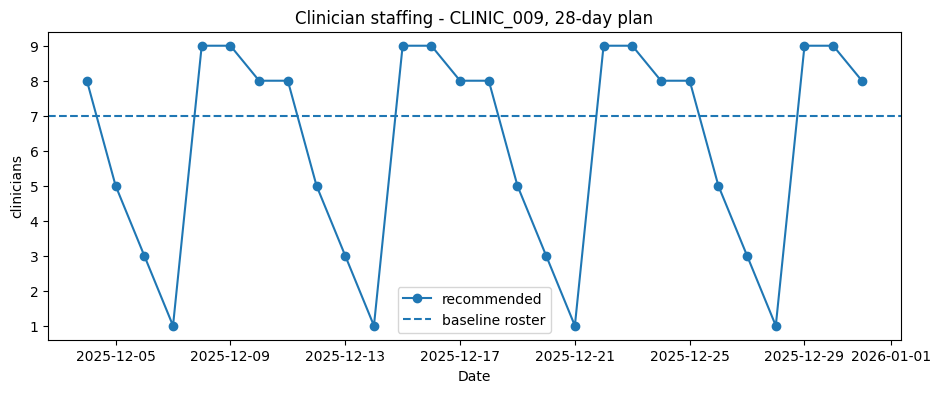

In [6]:
example_clinic = gap_summary.sort_values("mean_clinician_gap", ascending=False).index[0]
frame = gaps[gaps["clinic_id"] == example_clinic]

fig, ax = plt.subplots()
ax.plot(frame["date"], frame["recommended_clinicians"], marker="o", label="recommended")
ax.axhline(frame["base_clinicians"].iloc[0], linestyle="--", label="baseline roster")
ax.set_title(f"Clinician staffing - {example_clinic}, 28-day plan")
ax.set_xlabel("Date")
ax.set_ylabel("clinicians")
ax.legend()
plt.show()

## Conservative staffing from prediction intervals

The 12% flat buffer above is a blunt instrument: it ignores that some clinics
are far harder to forecast than others (notebook 04 measured a multi-x WAPE
spread). A better safety margin comes from **conformal prediction intervals**:
staff to the 90% upper bound, and each clinic's buffer automatically scales
with its own demonstrated forecast error.

The workflow below is exactly what the batch pipeline will productionise:
calibrate intervals on rolling validation folds, fit the global ML model,
forecast the planning window recursively (no future targets), attach
per-clinic intervals, and staff to the upper bound with *no additional* flat
buffer — the interval replaces it.

In [7]:
from clinic_forecast.intervals import ConformalIntervals
from clinic_forecast.models.global_ml import GlobalMLForecaster
from clinic_forecast.validation import RollingOriginSplitter

splitter = RollingOriginSplitter(initial_train_days=365 * 3, horizon_days=28, max_folds=2)
calibration_frames = []
for cal_train, cal_test, fold in splitter.split(train):
    cal_model = GlobalMLForecaster().fit(cal_train)
    combined = pd.concat([cal_train, cal_test], ignore_index=True).sort_values(
        ["clinic_id", "date"]
    )
    preds = cal_model.predict_known_future(combined)
    preds = preds[preds["date"] >= fold.test_start]
    calibration_frames.append(
        cal_test.merge(preds[["clinic_id", "date", "forecast"]],
                       on=["clinic_id", "date"], how="inner")
    )
calibration = pd.concat(calibration_frames, ignore_index=True)

ml_model = GlobalMLForecaster().fit(train)
ml_forecast = ml_model.forecast(history=train, future=future.drop(columns=["visits"]))
conformal = ConformalIntervals(coverage=0.9, group_col="clinic_id").fit(calibration)
ml_intervals = conformal.apply(ml_forecast)
ml_intervals.head()

,clinic_id,date,forecast,model,y_pred,y_lower,y_upper
0,CLINIC_001,2025-12-04,97.435743,global_ml_hgb,97.435743,59.531317,135.340168
1,CLINIC_002,2025-12-04,159.837467,global_ml_hgb,159.837467,88.986721,230.688213
2,CLINIC_003,2025-12-04,32.293348,global_ml_hgb,32.293348,12.787022,51.799674
3,CLINIC_004,2025-12-04,62.515096,global_ml_hgb,62.515096,10.740312,114.289880
4,CLINIC_005,2025-12-04,25.558367,global_ml_hgb,25.558367,4.884362,46.232373


In [8]:
no_buffer = StaffingRules(buffer_ratio=0.0)
mean_plan = recommend_staffing(ml_intervals, forecast_col="y_pred", rules=no_buffer)
upper_plan = recommend_staffing(ml_intervals, forecast_col="y_upper", rules=no_buffer)

plans = future[["clinic_id", "date", "visits"]].merge(
    mean_plan[["clinic_id", "date", "recommended_clinicians"]]
    .rename(columns={"recommended_clinicians": "clinicians_mean_plan"}),
    on=["clinic_id", "date"],
).merge(
    upper_plan[["clinic_id", "date", "recommended_clinicians"]]
    .rename(columns={"recommended_clinicians": "clinicians_upper_plan"}),
    on=["clinic_id", "date"],
)

summary = {}
for plan in ["mean_plan", "upper_plan"]:
    capacity = plans[f"clinicians_{plan}"] * 18
    summary[plan] = {
        "clinician_days": int(plans[f"clinicians_{plan}"].sum()),
        "days_understaffed_vs_actuals": int((plans["visits"] > capacity).sum()),
    }
pd.DataFrame(summary).T

,clinician_days,days_understaffed_vs_actuals
mean_plan,1501,121
upper_plan,2328,8


Read the two rows as the operational trade-off:

- The **mean plan** is cheaper but leaves a material number of clinic-days
  understaffed whenever demand lands above the point forecast — which, by
  construction, is about half the time it deviates at all.
- The **upper-bound plan** buys near-complete protection against
  understaffing on this window for a quantified extra headcount cost — and
  unlike the flat buffer, that cost is allocated where forecast risk actually
  is: volatile clinics get more slack, predictable clinics run lean.

The residual understaffed days under the upper plan are the 90%-coverage tail
plus capacity-censored peaks — the irreducible part that overtime and float
pools exist for.

## The decision in money: scenario comparison

Headcounts persuade operations managers; money persuades leadership. The cost
model in `configs/staffing.yaml` prices four components per clinic-day:
regular staff (day rates by role), overtime (demand above regular clinician
capacity, served up to a 1.2x stretch at a 1.5x premium), an understaffing
penalty per visit that even overtime cannot absorb, and idle capacity charged
at half the day rate.

Three plans are costed against the *realised* demand of the planning window,
on open days only:

1. **Current static roster** — each clinic's baseline headcount every day.
2. **Forecast mean plan** — staff to the global ML point forecast.
3. **Conservative upper plan** — staff to the 90% conformal upper bound.

In [9]:
from clinic_forecast.staffing import compare_staffing_scenarios, load_staffing_config

rules_cfg, costs_cfg = load_staffing_config(PROJECT_ROOT / "configs" / "staffing.yaml")

future_open = future[future["is_open"] == 1][["clinic_id", "date", "visits"]]

current_plan = future_open.merge(
    metadata[["clinic_id", "base_clinicians", "base_nurses", "base_frontdesk"]],
    on="clinic_id",
).rename(columns={
    "base_clinicians": "recommended_clinicians",
    "base_nurses": "recommended_nurses",
    "base_frontdesk": "recommended_frontdesk",
})


def against_actuals(plan: pd.DataFrame) -> pd.DataFrame:
    staffed_cols = ["recommended_clinicians", "recommended_nurses", "recommended_frontdesk"]
    return future_open.merge(
        plan[["clinic_id", "date", *staffed_cols]], on=["clinic_id", "date"], how="inner"
    )


scenario_summary = compare_staffing_scenarios(
    {
        "current_static_roster": current_plan,
        "forecast_mean_plan": against_actuals(mean_plan),
        "conservative_upper_plan": against_actuals(upper_plan),
    },
    rules=rules_cfg,
    costs=costs_cfg,
)
scenario_summary.round(0)

,scenario,regular_cost,overtime_cost,understaffing_cost,idle_cost,total_cost,understaffed_days,clinician_days
0,forecast_mean_plan,1405500.0,82550.0,49360.0,51650.0,1589060.0,47,1428
1,conservative_upper_plan,2067900.0,1600.0,0.0,220183.0,2289683.0,0,2114
2,current_static_roster,2353400.0,34450.0,0.0,206533.0,2594383.0,0,2032


How to read the table:

- **Total cost** is the headline, but the *composition* is the story. The
  static roster pays for the same staff every day and converts the weekly
  demand cycle directly into a mix of idle cost (quiet days) and
  overtime/understaffing cost (peaks).
- The **mean plan** minimises regular cost but exposes the network to
  overtime and penalty costs whenever demand lands above the point forecast.
- The **upper plan** shifts money from penalties into planned regular
  staffing. Under the default coefficients the mean plan still wins on total
  cost — the 80-per-visit penalty does not fully price waiting times,
  clinician burnout and reputational damage. Whether dozens of understaffed
  clinic-days are acceptable at that price is precisely the judgement this
  table hands to leadership rather than hiding inside a model.
- The **static roster** loses on both fronts: it spends more than the upper
  plan while still paying overtime on peak days, because the same headcount
  shows up regardless of the weekly cycle.

Because every coefficient lives in `configs/staffing.yaml`, leadership can
stress-test the conclusion under their own cost beliefs — double the
understaffing penalty, halve the idle penalty — without touching code.

## Scheduled vs realised demand: forecasting no-shows

Everything above staffs against *completed visits*, but different roles face
different demand: front-desk and room load follow the **schedule**, while
clinical workload follows **completed visits**. The gap — no-shows plus
same-day cancellations — averages around a tenth of the schedule and differs
structurally between clinics, so it is worth forecasting in its own right.

Two models for the attrition rate, evaluated on the planning window:

- **Historical mean** per clinic and weekday (captures the Monday effect and
  clinic-level differences — the baseline).
- **Global ML** retargeted at the attrition rate, with all same-day outcome
  columns (including visits) removed from its features.

In [10]:
from clinic_forecast.evaluation import comparison_table, evaluate_forecasts
from clinic_forecast.noshow import (
    ATTRITION_TARGET,
    AttritionRateForecaster,
    build_noshow_targets,
    expected_completed_visits,
    forecast_attrition_rate_baseline,
)

future_targets = build_noshow_targets(future)
open_future = future_targets[future_targets["scheduled_appointments"] > 0]

baseline_rate = forecast_attrition_rate_baseline(train, open_future)
rate_model = AttritionRateForecaster().fit(train)
combined_usage = pd.concat([train, future], ignore_index=True).sort_values(
    ["clinic_id", "date"]
)
ml_rate = rate_model.predict_known_future(combined_usage)
ml_rate = ml_rate[ml_rate["date"] > cutoff]

rate_scored = pd.concat(
    [
        open_future.merge(frame[["clinic_id", "date", "forecast", "model"]],
                          on=["clinic_id", "date"], how="inner")
        for frame in (baseline_rate, ml_rate)
    ],
    ignore_index=True,
)
comparison_table(
    evaluate_forecasts(rate_scored, actual_col=ATTRITION_TARGET),
    metrics=("mae", "rmse", "bias"),
)

,mae,rmse,bias
model,,,
attrition_global_ml,0.001,0.003,0.281
attrition_historical_mean,0.031,0.043,-2.166


The rates are small numbers, so read MAE in rate points (0.01 = one
percentage point of the schedule). The historical mean is a strong baseline —
attrition is far more stable than demand — and the ML model's margin is
modest. That is itself a useful finding: a transparent clinic-by-weekday
lookup table captures most of the signal, which is what should ship first.

## Using both targets

With a schedule forecast and a rate forecast, expected completed visits
follow mechanically — and each role gets the right target:

In [11]:
schedule_forecast = (
    open_future[["clinic_id", "date", "scheduled_appointments"]]
    .rename(columns={"scheduled_appointments": "forecast"})
)
completed = expected_completed_visits(schedule_forecast, ml_rate)

network_view = completed.groupby("date")[["scheduled", "expected_completed"]].sum()
print("Planning window, network totals:")
print(f"  scheduled appointments: {network_view['scheduled'].sum():,.0f}")
print(f"  expected completed:     {network_view['expected_completed'].sum():,.0f}")
gap = 1 - network_view["expected_completed"].sum() / network_view["scheduled"].sum()
print(f"  expected attrition:     {gap:.1%}")
print()
print("Role-to-target mapping: front-desk and rooms staff to *scheduled*;")
print("clinicians staff to *expected completed*; the gap itself is the")
print("target for reminder campaigns and overbooking policy.")

Planning window, network totals:
  scheduled appointments: 29,401
  expected completed:     25,822
  expected attrition:     12.2%

Role-to-target mapping: front-desk and rooms staff to *scheduled*;
clinicians staff to *expected completed*; the gap itself is the
target for reminder campaigns and overbooking policy.


## Sensitivity: how much does the buffer cost?

The buffer ratio is the policy lever that trades service risk against cost.
Sweeping it shows the staffing bill's sensitivity — the relationship is
stepwise (staff are integers), so small buffer changes are often free until
they cross a threshold.

In [12]:
sweep_rows = []
for buffer in [0.0, 0.06, 0.12, 0.20, 0.30]:
    swept = recommend_staffing(
        forecast,
        rules=StaffingRules(buffer_ratio=buffer),
    )
    sweep_rows.append({
        "buffer_ratio": buffer,
        "total_clinician_days": int(swept["recommended_clinicians"].sum()),
        "total_nurse_days": int(swept["recommended_nurses"].sum()),
        "total_frontdesk_days": int(swept["recommended_frontdesk"].sum()),
    })
sweep = pd.DataFrame(sweep_rows)
sweep["clinician_days_vs_no_buffer"] = (
    sweep["total_clinician_days"] - sweep.loc[0, "total_clinician_days"]
)
sweep

,buffer_ratio,total_clinician_days,total_nurse_days,total_frontdesk_days,clinician_days_vs_no_buffer
0,0.00,1556,1220,884,0
1,0.06,1640,1264,920,84
2,0.12,1708,1336,972,152
3,0.20,1820,1396,1028,264
4,0.30,1968,1524,1088,412


Each buffer step buys insurance against under-forecasting at a quantifiable
headcount cost. Choosing the right point on this curve is an operations
decision, not a modelling one — but the model makes the trade-off explicit
instead of implicit in habit.

## Limitations and next steps

Honest accounting of what this layer does *not* yet do:

1. **Role-specific demand drivers.** Nurses and front-desk staff are sized
   from total visits; in reality front-desk load follows *scheduled
   appointments* (including future no-shows) while clinical load follows
   completed visits. The schedule/realised split in the data supports this —
   wiring it in is a planned extension.
2. **Within-day shape.** Daily totals hide intra-day arrival peaks; true
   rostering needs hour-level profiles. Out of scope for this PoC and called
   out in the model card.
3. **Cost coefficients are assumptions.** The YAML values are deliberately
   round; the scenario ranking can flip under different penalty beliefs, and
   the right way to use this layer is to present the ranking *as a function
   of* those beliefs.
4. **Recalibration cadence.** Interval widths come from past validation
   residuals; after demand regime changes they need refreshing — the
   monitoring stage in the roadmap covers exactly this trigger.
